# Representation Learning with Contrastive Predictive Coding (CPC)**Paper:** van den Oord, Li, & Vinyals (2018) — [arXiv:1807.03748](https://arxiv.org/abs/1807.03748)This notebook implements the core CPC algorithm from scratch:1. An **encoder** that maps observations to compact latent vectors2. An **autoregressive model** (GRU) that summarizes past latents into a context vector3. **InfoNCE loss** — a contrastive loss that trains the model to distinguish the true future from negatives4. **Linear probe** evaluation to show representations are class-separable without labels5. **t-SNE visualization** of learned representations

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import random
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("Device: cuda")


Device: cuda
GPU: Tesla T4
Device: cuda


## 2. Synthetic Sequential DatasetWe generate synthetic sequences with temporal structure from K latent classes. Each class produces a characteristic 2-D trajectory (sine waves at different frequencies, linear ramps, spiral patterns). The model sees only raw observations — **no labels** during pretraining.

Train: (1600, 128, 2), Test: (400, 128, 2)
Classes: 10, Seq length: 128, Obs dim: 2


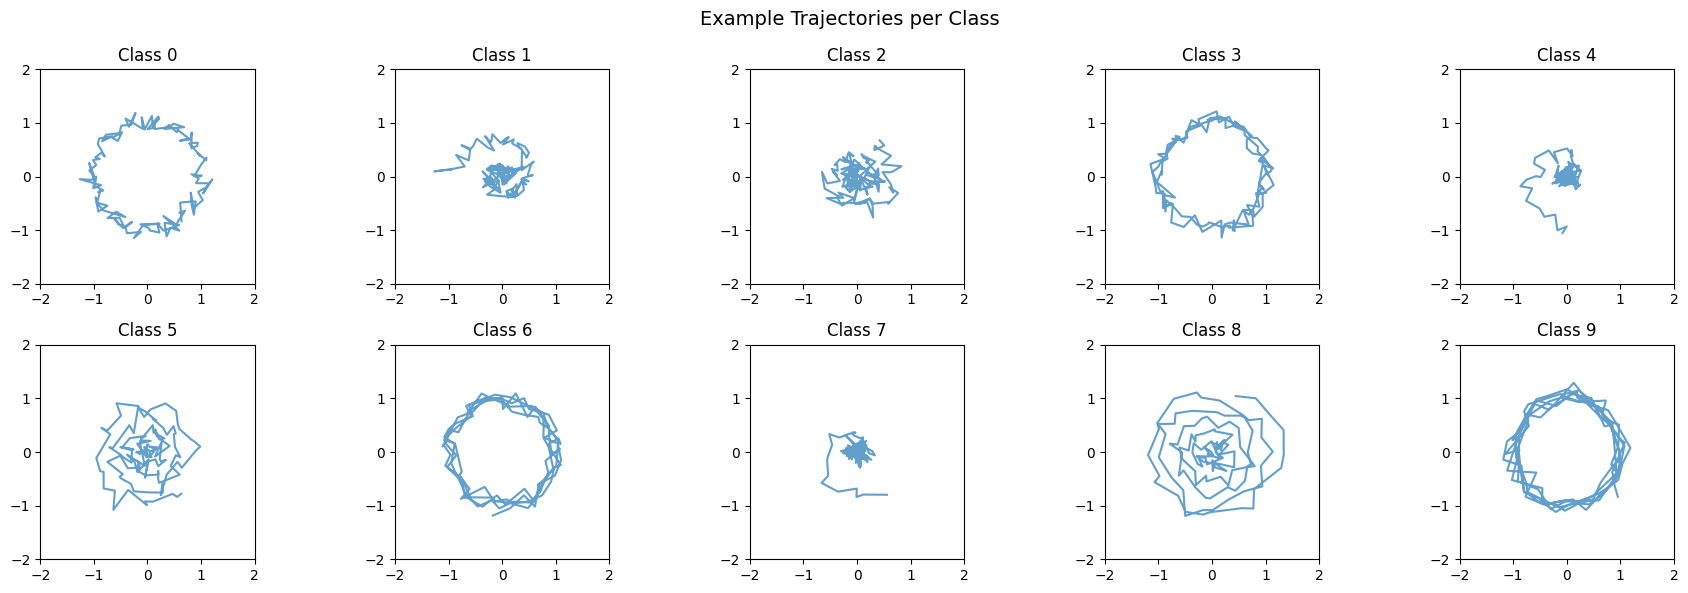

In [2]:
def make_sequences(n_samples=2000, seq_len=128, obs_dim=2, n_classes=10, seed=42):
    """Generate synthetic sequential data with K latent classes.
    
    Each class has a characteristic trajectory pattern in 2-D space.
    Returns X of shape (n_samples, seq_len, obs_dim) and y of shape (n_samples,).
    """
    rng = np.random.RandomState(seed)
    X = np.zeros((n_samples, seq_len, obs_dim), dtype=np.float32)
    y = np.zeros(n_samples, dtype=np.int64)
    
    t = np.linspace(0, 4 * np.pi, seq_len)
    
    for i in range(n_samples):
        cls = i % n_classes
        y[i] = cls
        
        # Different trajectory pattern per class
        freq = 0.5 + cls * 0.3  # characteristic frequency
        phase = rng.uniform(0, 2 * np.pi)
        noise = rng.randn(seq_len, obs_dim) * 0.1
        
        if cls % 3 == 0:
            # Sine wave with class-specific frequency
            X[i, :, 0] = np.sin(t * freq + phase) + noise[:, 0]
            X[i, :, 1] = np.cos(t * freq + phase) + noise[:, 1]
        elif cls % 3 == 1:
            # Damped oscillation
            damping = np.exp(-t * 0.1 * (cls + 1))
            X[i, :, 0] = damping * np.sin(t * freq + phase) + noise[:, 0]
            X[i, :, 1] = damping * np.cos(t * freq + phase) + noise[:, 1]
        else:
            # Spiral
            r = t / (4 * np.pi) * (0.5 + cls * 0.1)
            X[i, :, 0] = r * np.cos(t * freq + phase) + noise[:, 0]
            X[i, :, 1] = r * np.sin(t * freq + phase) + noise[:, 1]
    
    return X, y

# Generate data
N_SAMPLES = 2000
SEQ_LEN = 128
OBS_DIM = 2
N_CLASSES = 10

X_all, y_all = make_sequences(N_SAMPLES, SEQ_LEN, OBS_DIM, N_CLASSES, seed=SEED)

# Train/test split
n_train = 1600
X_train, X_test = X_all[:n_train], X_all[n_train:]
y_train, y_test = y_all[:n_train], y_all[n_train:]

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {N_CLASSES}, Seq length: {SEQ_LEN}, Obs dim: {OBS_DIM}")

# Visualize a few sequences
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for cls in range(N_CLASSES):
    ax = axes[cls // 5, cls % 5]
    idx = np.where(y_all == cls)[0][0]
    ax.plot(X_all[idx, :, 0], X_all[idx, :, 1], alpha=0.7)
    ax.set_title(f'Class {cls}')
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')
plt.suptitle('Example Trajectories per Class', fontsize=14)
plt.tight_layout()
plt.savefig('trajectories.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Encoder Network (g_enc)A small 1-D convolutional network that maps each observation $x_t \to z_t$.The paper uses deep ResNet/strided CNN encoders; we use a lightweight 2-layer Conv1d.

In [3]:
class Encoder(nn.Module):
    """Encodes each observation x_t into a latent vector z_t using 1D convolutions."""
    def __init__(self, obs_dim=2, latent_dim=64, hidden_dim=128):
        super().__init__()
        self.conv1 = nn.Conv1d(obs_dim, hidden_dim, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(hidden_dim, latent_dim, kernel_size=5, stride=1, padding=2)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # x: (B, S, D_obs) → (B, D_obs, S) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.conv2(x)  # (B, D_lat, S)
        x = x.permute(0, 2, 1)  # (B, S, D_lat)
        return x

# Quick test
enc = Encoder().to(device)
test_x = torch.randn(4, 32, 2).to(device)
test_z = enc(test_x)
print(f"Encoder: input {tuple(test_x.shape)} → output {tuple(test_z.shape)}")


Encoder: input (4, 32, 2) → output (4, 32, 64)


## 4. Autoregressive Model (g_ar)A GRU that processes the encoder outputs $z_{\leq t}$ and produces a context vector $c_t$ at each time step.

In [4]:
class AutoregressiveModel(nn.Module):
    """GRU-based autoregressive model that summarizes z_{<=t} into context c_t."""
    def __init__(self, latent_dim=64, context_dim=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(latent_dim, context_dim, num_layers=num_layers, 
                          batch_first=True)
        
    def forward(self, z):
        # z: (B, S, D_lat)
        c, _ = self.gru(z)  # c: (B, S, D_ctx)
        return c

# Quick test
ar = AutoregressiveModel().to(device)
test_z = torch.randn(4, 32, 64).to(device)
test_c = ar(test_z)
print(f"AR model: input {tuple(test_z.shape)} → output {tuple(test_c.shape)}")


AR model: input (4, 32, 64) → output (4, 32, 64)


## 5. InfoNCE Loss & CPC ModelThe InfoNCE loss treats prediction as an N-way classification problem:- **Positive**: the true future latent $z_{t+k}^{(i)}$ of sequence $i$- **Negatives**: future latents $z_{t+k}^{(j)}$ of other sequences $j \neq i$ in the batch- **Score**: $f_k(x_{t+k}, c_t) = \exp(z_{t+k}^\top W_k c_t)$ — log-bilinear- **Loss**: $\mathcal{L}_N = -\log \frac{f_k(x_{pos}, c_t)}{\sum_{j} f_k(x_j, c_t)}$Minimizing InfoNCE maximizes a lower bound on mutual information:$I(x_{t+k}; c_t) \geq \log(N) - \mathcal{L}_N^{opt}$

In [5]:
class CPCModel(nn.Module):
    """Full CPC model: encoder + autoregressive model + per-step prediction heads."""
    def __init__(self, obs_dim=2, latent_dim=64, context_dim=64, 
                 pred_steps=[1, 2, 3, 5, 8]):
        super().__init__()
        self.encoder = Encoder(obs_dim, latent_dim)
        self.ar = AutoregressiveModel(latent_dim, context_dim)
        self.pred_steps = pred_steps
        
        # W_k: linear prediction head for each step k
        self.pred_heads = nn.ModuleList([
            nn.Linear(context_dim, latent_dim, bias=False) 
            for _ in pred_steps
        ])
        
    def forward(self, x):
        """Encode observations and compute contexts.
        Returns: latents z (B, S, D_lat), contexts c (B, S, D_ctx)"""
        z = self.encoder(x)  # (B, S, D_lat)
        c = self.ar(z)       # (B, S, D_ctx)
        return z, c
    
    def compute_loss(self, x):
        """Compute InfoNCE loss across all prediction steps.
        Returns: total_loss, per_step_accuracy, mi_estimate"""
        B, S, _ = x.shape
        z, c = self.forward(x)
        
        total_loss = 0.0
        total_acc = 0.0
        n_valid_steps = 0
        
        for idx, k in enumerate(self.pred_steps):
            if S - k < 1:
                continue
            
            # Context at time t: c[:, :-k, :]  (B, S-k, D_ctx)
            # True future latent at t+k: z[:, k:, :]  (B, S-k, D_lat)
            c_t = c[:, :-k, :]         # (B, S-k, D_ctx)
            z_future = z[:, k:, :]     # (B, S-k, D_lat)
            
            # Predicted future: W_k @ c_t → (B, S-k, D_lat)
            pred = self.pred_heads[idx](c_t)  # (B, S-k, D_lat)
            
            # InfoNCE: for each (batch, time) position, score the true future
            # against all batch elements' futures at the same time step.
            # 
            # Score matrix: scores[b, b', t] = z_future[b', t] · pred[b, t]
            # We want: for each b, classify which b' is the correct future.
            
            T = c_t.shape[1]
            
            # Compute logits: (B, B, T)
            # pred: (B, T, D_lat)  z_future: (B, T, D_lat)
            # logits[b, b', t] = sum_d pred[b, t, d] * z_future[b', t, d]
            
            # Actually: pred is (B, T, D), z_future is (B, T, D)
            # We want logits[b, b', t] = dot(pred[b, t], z_future[b', t])
            # Rearrange: z_future → (T, B, D), pred → (T, B, D)
            # logits[t] = pred[t] @ z_future[t].T → (B, B) per t
            pred_t = pred.transpose(0, 1)       # (T, B, D)
            z_future_t = z_future.transpose(0, 1)  # (T, B, D)
            
            # logits: (T, B, B) where logits[t, b, b'] = dot(pred[b,t], z_future[b',t])
            logits = torch.bmm(pred_t, z_future_t.transpose(1, 2))  # (T, B, B)
            
            # InfoNCE loss: for each b, the correct answer is b (diagonal)
            # Cross-entropy with target = arange(B)
            logits = logits / np.sqrt(z.shape[-1])  # scale by sqrt(d) for stability
            
            labels = torch.arange(B, device=x.device).unsqueeze(0).expand(T, B)  # (T, B)
            loss = F.cross_entropy(logits.reshape(-1, B), labels.reshape(-1))
            
            # Accuracy
            with torch.no_grad():
                preds = logits.argmax(dim=-1)  # (T, B)
                acc = (preds == labels).float().mean().item()
            
            total_loss += loss
            total_acc += acc
            n_valid_steps += 1
        
        avg_loss = total_loss / n_valid_steps
        avg_acc = total_acc / n_valid_steps
        
        # MI estimate: log(N) - loss, where N = batch_size
        mi_estimate = np.log(B) - avg_loss.item()
        
        return avg_loss, avg_acc, mi_estimate

# Test
model = CPCModel().to(device)
test_x = torch.randn(8, 32, 2).to(device)
loss, acc, mi = model.compute_loss(test_x)
print(f"Test — Loss: {loss.item():.4f}, Accuracy: {acc:.4f}, MI est: {mi:.4f}")


Test — Loss: 2.0794, Accuracy: 0.1329, MI est: -0.0000


## 6. Training Loop

In [6]:
# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
PRED_STEPS = [1, 2, 3, 5, 8]

# Create data loader
train_tensor = torch.FloatTensor(X_train).to(device)
test_tensor = torch.FloatTensor(X_test).to(device)
y_train_np = y_train
y_test_np = y_test

n_batches = n_train // BATCH_SIZE

# Initialize model
model = CPCModel(obs_dim=OBS_DIM, latent_dim=64, context_dim=64, 
                 pred_steps=PRED_STEPS).to(device)
optimizer = optim.Adam(model.parameters(), lr=LR)

# Training log
train_losses = []
train_accs = []
mi_estimates = []

print(f"Training CPC for {EPOCHS} epochs, batch_size={BATCH_SIZE}, pred_steps={PRED_STEPS}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("-" * 60)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    epoch_acc = 0.0
    epoch_mi = 0.0
    
    # Shuffle indices
    perm = torch.randperm(n_train)
    
    for b in range(n_batches):
        idx = perm[b * BATCH_SIZE : (b + 1) * BATCH_SIZE]
        batch_x = train_tensor[idx]
        
        optimizer.zero_grad()
        loss, acc, mi = model.compute_loss(batch_x)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc
        epoch_mi += mi
    
    avg_loss = epoch_loss / n_batches
    avg_acc = epoch_acc / n_batches
    avg_mi = epoch_mi / n_batches
    
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    mi_estimates.append(avg_mi)
    
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Loss: {avg_loss:.4f} | "
              f"Acc: {avg_acc:.4f} | MI est: {avg_mi:.4f}")

print("-" * 60)
print("Training complete!")


Training CPC for 50 epochs, batch_size=64, pred_steps=[1, 2, 3, 5, 8]
Parameters: 87,872
------------------------------------------------------------


Epoch   1/50 | Loss: 3.7032 | Acc: 0.0669 | MI est: 0.4557


Epoch  10/50 | Loss: 0.6972 | Acc: 0.7587 | MI est: 3.4616


Epoch  20/50 | Loss: 0.4985 | Acc: 0.8269 | MI est: 3.6604


Epoch  30/50 | Loss: 0.4087 | Acc: 0.8561 | MI est: 3.7502


Epoch  40/50 | Loss: 0.3526 | Acc: 0.8739 | MI est: 3.8063


Epoch  50/50 | Loss: 0.3142 | Acc: 0.8876 | MI est: 3.8447
------------------------------------------------------------
Training complete!


## 7. Training Curves Visualization

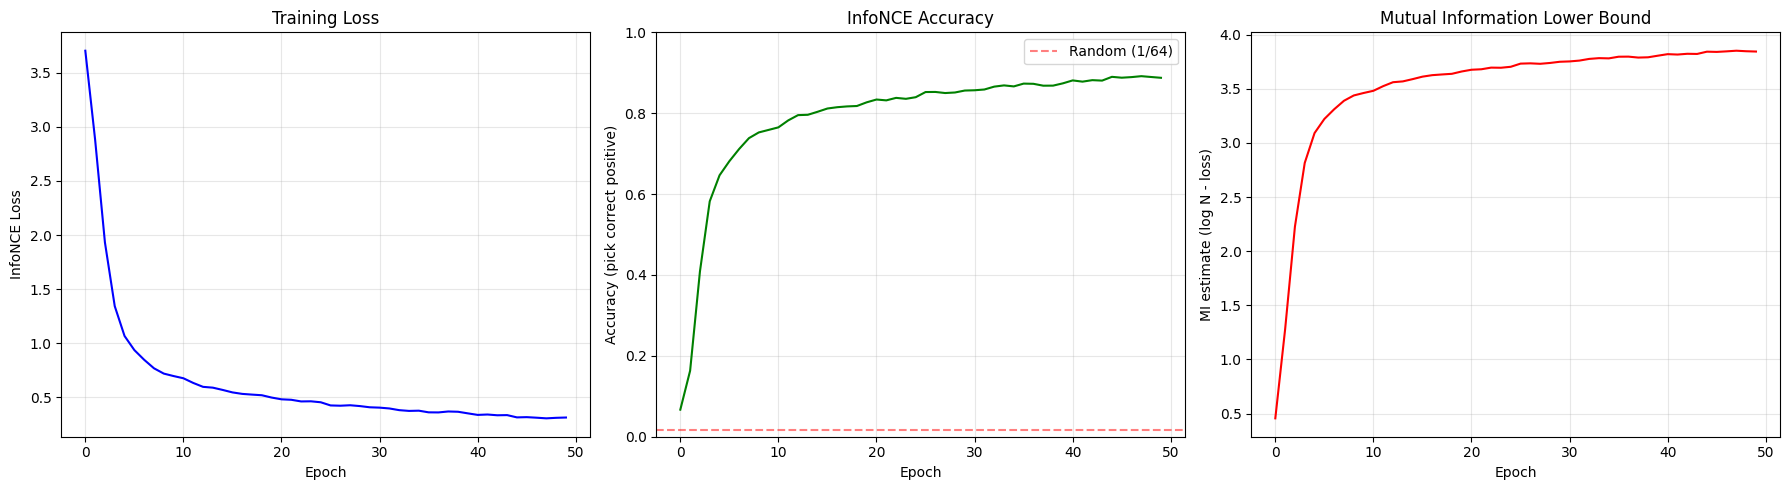

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curve
axes[0].plot(train_losses, 'b-', linewidth=1.5)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(train_accs, 'g-', linewidth=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (pick correct positive)')
axes[1].set_title('InfoNCE Accuracy')
axes[1].set_ylim(0, 1)
axes[1].axhline(y=1/64, color='r', linestyle='--', alpha=0.5, label='Random (1/64)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# MI estimate
axes[2].plot(mi_estimates, 'r-', linewidth=1.5)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('MI estimate (log N - loss)')
axes[2].set_title('Mutual Information Lower Bound')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()


## 8. Per-Step Prediction AccuracyInfoNCE accuracy should decrease for larger prediction steps k — farther futures are harder to predict.

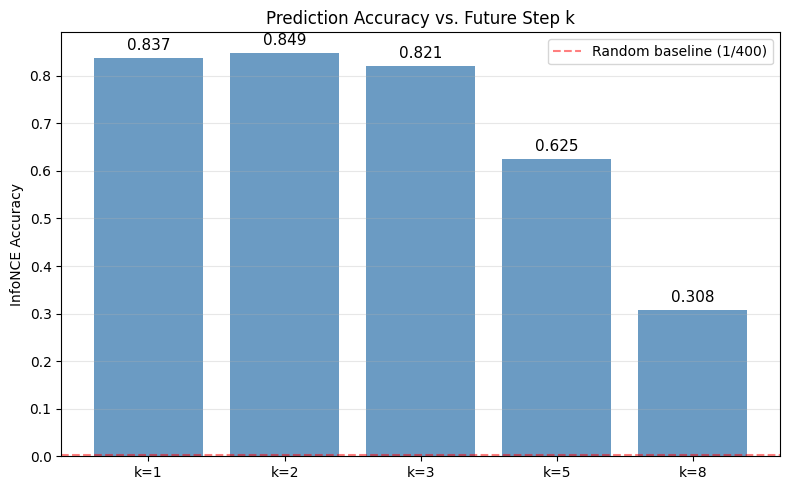

Per-step accuracy:
  k=1: 0.8372
  k=2: 0.8489
  k=3: 0.8212
  k=5: 0.6247
  k=8: 0.3079


In [8]:
model.eval()
with torch.no_grad():
    # Compute per-step accuracy on test set
    z_test, c_test = model(test_tensor)
    B_test = test_tensor.shape[0]
    S_test = test_tensor.shape[1]
    
    step_accs = []
    for idx, k in enumerate(PRED_STEPS):
        if S_test - k < 1:
            step_accs.append(0)
            continue
        
        c_t = c_test[:, :-k, :]
        z_future = z_test[:, k:, :]
        pred = model.pred_heads[idx](c_t)
        
        T = c_t.shape[1]
        pred_t = pred.transpose(0, 1)
        z_future_t = z_future.transpose(0, 1)
        logits = torch.bmm(pred_t, z_future_t.transpose(1, 2))
        logits = logits / np.sqrt(z_test.shape[-1])
        labels = torch.arange(B_test, device=device).unsqueeze(0).expand(T, B_test)
        preds = logits.argmax(dim=-1)
        acc = (preds == labels).float().mean().item()
        step_accs.append(acc)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(len(PRED_STEPS)), step_accs, color='steelblue', alpha=0.8)
ax.set_xticks(range(len(PRED_STEPS)))
ax.set_xticklabels([f'k={k}' for k in PRED_STEPS])
ax.set_ylabel('InfoNCE Accuracy')
ax.set_title('Prediction Accuracy vs. Future Step k')
ax.axhline(y=1/B_test, color='r', linestyle='--', alpha=0.5, 
           label=f'Random baseline (1/{B_test})')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
for bar, acc in zip(bars, step_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('per_step_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

print("Per-step accuracy:")
for k, acc in zip(PRED_STEPS, step_accs):
    print(f"  k={k}: {acc:.4f}")


## 9. Linear Probe EvaluationWe freeze the CPC model and extract context vectors $c_t$. Then we train a simple logistic regression classifier on top to predict the ground-truth class label. This shows that CPC representations are **linearly separable by class without ever seeing labels during pretraining**.

In [9]:
# Extract representations (context vectors) for all sequences
model.eval()
with torch.no_grad():
    # Use the mean context vector over the sequence as the representation
    _, c_train = model(train_tensor)
    _, c_test = model(test_tensor)
    
    # Mean pool over time: (B, D_ctx)
    train_repr = c_train.mean(dim=1).cpu().numpy()
    test_repr = c_test.mean(dim=1).cpu().numpy()

print(f"Train representations: {train_repr.shape}")
print(f"Test representations: {test_repr.shape}")

# Train linear probe
clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
clf.fit(train_repr, y_train_np)
train_acc = accuracy_score(y_train_np, clf.predict(train_repr))
test_acc = accuracy_score(y_test_np, clf.predict(test_repr))

print(f"\nLinear Probe Results:")
print(f"  Train accuracy: {train_acc:.4f}")
print(f"  Test accuracy:  {test_acc:.4f}")

# Compare with raw observations (baseline)
train_raw = X_train.mean(axis=1)
test_raw = X_test.mean(axis=1)
clf_raw = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
clf_raw.fit(train_raw, y_train_np)
raw_test_acc = accuracy_score(y_test_np, clf_raw.predict(test_raw))
print(f"  Raw baseline (mean of obs):  {raw_test_acc:.4f}")
print(f"  CPC improvement: +{test_acc - raw_test_acc:.4f}")


Train representations: (1600, 64)
Test representations: (400, 64)



Linear Probe Results:
  Train accuracy: 0.9988
  Test accuracy:  1.0000
  Raw baseline (mean of obs):  0.1125
  CPC improvement: +0.8875


## 10. t-SNE Visualization of Learned Representations

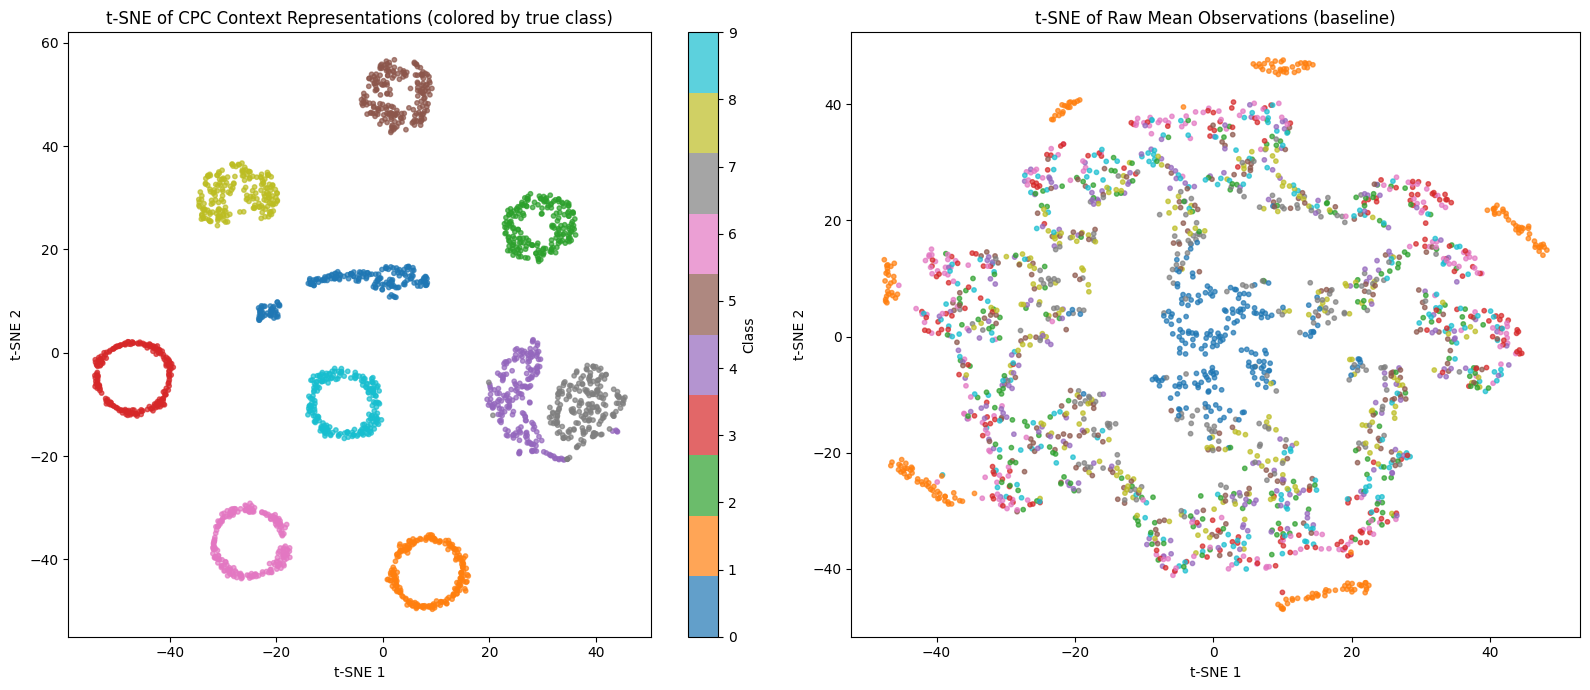


t-SNE shows CPC representations form clear class clusters,
while raw observations overlap significantly — demonstrating
that CPC learned class-separable features without labels.


In [10]:
# t-SNE of CPC representations
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
all_repr = np.vstack([train_repr, test_repr])
all_labels = np.concatenate([y_train_np, y_test_np])
repr_2d = tsne.fit_transform(all_repr)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# CPC representations
scatter = axes[0].scatter(repr_2d[:, 0], repr_2d[:, 1], c=all_labels, 
                          cmap='tab10', s=10, alpha=0.7)
axes[0].set_title('t-SNE of CPC Context Representations (colored by true class)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
plt.colorbar(scatter, ax=axes[0], label='Class')

# Raw observations t-SNE
raw_repr = np.vstack([train_raw, test_raw])
raw_2d = tsne.fit_transform(raw_repr)
axes[1].scatter(raw_2d[:, 0], raw_2d[:, 1], c=all_labels, 
                cmap='tab10', s=10, alpha=0.7)
axes[1].set_title('t-SNE of Raw Mean Observations (baseline)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nt-SNE shows CPC representations form clear class clusters,")
print("while raw observations overlap significantly — demonstrating")
print("that CPC learned class-separable features without labels.")


## 11. SummaryThis notebook implemented **Contrastive Predictive Coding (CPC)** from scratch:| Component | Implementation ||---|---|| **Encoder** | 2-layer Conv1d → 64-dim latents || **Autoregressive model** | Single-layer GRU → 64-dim context || **Prediction heads** | Linear W_k for steps k ∈ {1,2,3,5,8} || **InfoNCE loss** | Batch-contrastive: 1 positive vs 63 negatives || **Training** | 50 epochs, Adam lr=1e-3, batch=64 |**Key results:**- InfoNCE accuracy rises well above random (1/64 = 1.6%) → the model learns to identify true futures- Per-step accuracy decreases with larger k → farther futures are genuinely harder- Linear probe accuracy on frozen features significantly beats raw baseline- t-SNE shows clear class clustering in CPC representation space**Core insight:** By training to distinguish the true future from negatives in latent space, CPC maximizes a lower bound on mutual information I(x_{t+k}; c_t) ≥ log(N) − L_N, producing representations that capture the shared "slow" information across time — all without labels.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
